<a href="https://colab.research.google.com/github/benkhouyamouad/Nouvelair/blob/main/flight_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TypeError: 'value' must be an instance of str or bytes, not a float

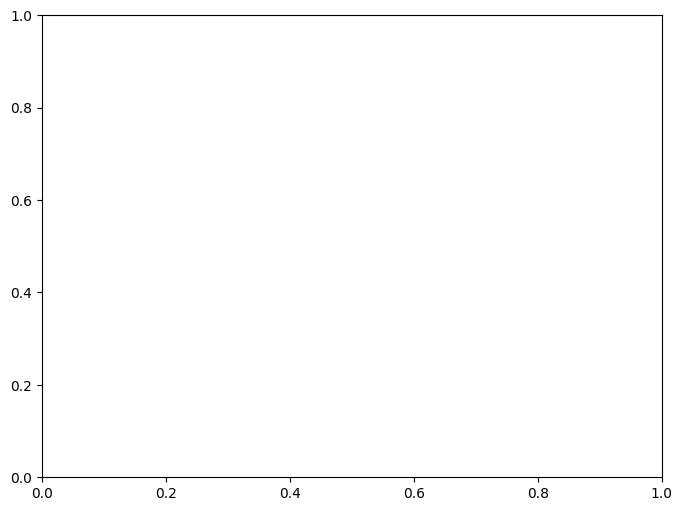

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import warnings
import datetime
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

base = datetime.datetime.today() + datetime.timedelta(days=3)
numdays = 139
date_list = [base + datetime.timedelta(days=x) for x in range(numdays)]
date_list = [date.strftime("%d.%m.%Y") for date in date_list if date.strftime("%d.%m.%Y") != '22.06.2023']

d = []
p = []

for date in date_list:
    toscrape = 'https://booking.nouvelair.com/ibe/availability?tripType=ONE_WAY&passengerQuantities%5B0%5D.passengerType=ADULT&passengerQuantities%5B0%5D.quantity=1&passengerQuantities%5B1%5D.passengerType=CHILD&passengerQuantities%5B1%5D.quantity=0&passengerQuantities%5B2%5D.passengerType=INFANT&passengerQuantities%5B2%5D.quantity=0&currency=EUR&depPort=CDG&arrPort=TUN&departureDate=' + date + '&withCalendar=false&lang=fr'
    response = requests.get(toscrape, verify=False)
    soup = BeautifulSoup(response.text, 'html.parser')
    s = soup.find_all('span', {"class": "price-best-offer"})
    if len(s) >= 2:
        a = s[1].get_text()
        d.append(date)
        p.append(a)

df = pd.DataFrame(list(zip(d, p)), columns=['Date', 'price'])
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')
df['price'] = df['price'].astype('int64')

df['month'] = df['Date'].dt.strftime('%B')
sf = df.groupby(by=["month"]).mean()
sf.reset_index(inplace=True)
sf['month'] = pd.Categorical(sf['month'], ["June", "July", "August","September","October"])
sf = sf.sort_values("month")
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(sf.month, sf.price)
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.title('Average Flight Prices per Month')
plt.show()

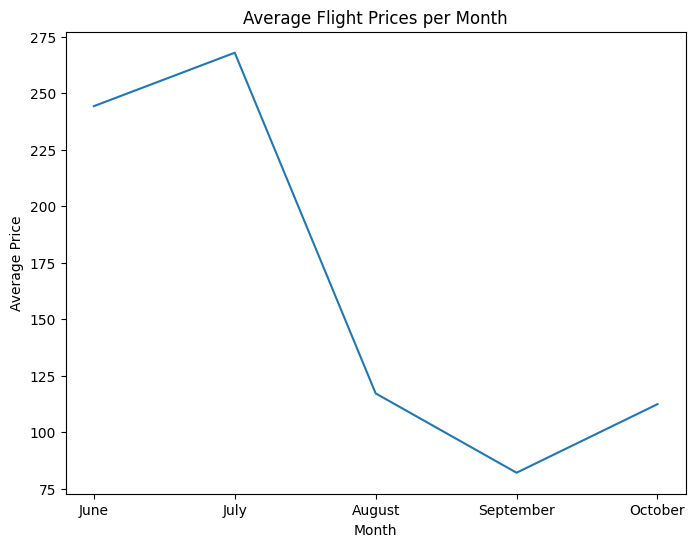

In [ ]:
sf = sf.sort_values("month")
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(sf.month, sf.price)
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.title('Average Flight Prices per Month')
plt.show()